# Oral Cancer Survival Prediction

A machine learning project to predict patient survival using clinical data.

### 🎯 Project Goal
To build a robust, human-like machine learning model that predicts the survival status of oral cancer patients with a realistic accuracy of around 85%.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline as sklearn_pipeline

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),Family History of Cancer,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,No,No,No,No,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,No,No,No,Yes,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,No,No,No,No,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,No,No,Yes,No,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,High,No,No,No,No,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  str    
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  str    
 4   Tobacco Use                               84922 non-null  str    
 5   Alcohol Consumption                       84922 non-null  str    
 6   HPV Infection                             84922 non-null  str    
 7   Betel Quid Use                            84922 non-null  str    
 8   Chronic Sun Exposure                      84922 non-null  str    
 9   Poor Oral Hygiene                         84922 non-null  str    
 10  Diet (Fruits & Vegetables Intake)         849

In [5]:
df.isnull().sum()

ID                                          0
Country                                     0
Age                                         0
Gender                                      0
Tobacco Use                                 0
Alcohol Consumption                         0
HPV Infection                               0
Betel Quid Use                              0
Chronic Sun Exposure                        0
Poor Oral Hygiene                           0
Diet (Fruits & Vegetables Intake)           0
Family History of Cancer                    0
Compromised Immune System                   0
Oral Lesions                                0
Unexplained Bleeding                        0
Difficulty Swallowing                       0
White or Red Patches in Mouth               0
Tumor Size (cm)                             0
Cancer Stage                                0
Treatment Type                              0
Survival Rate (5-Year, %)                   0
Cost of Treatment (USD)           

In [6]:
df.dtypes

ID                                            int64
Country                                         str
Age                                           int64
Gender                                          str
Tobacco Use                                     str
Alcohol Consumption                             str
HPV Infection                                   str
Betel Quid Use                                  str
Chronic Sun Exposure                            str
Poor Oral Hygiene                               str
Diet (Fruits & Vegetables Intake)               str
Family History of Cancer                        str
Compromised Immune System                       str
Oral Lesions                                    str
Unexplained Bleeding                            str
Difficulty Swallowing                           str
White or Red Patches in Mouth                   str
Tumor Size (cm)                             float64
Cancer Stage                                  int64
Treatment Ty

In [7]:
label_encoder = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
  df[col] = label_encoder.fit_transform(df[col])


In [8]:
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),Family History of Cancer,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,6,36,0,1,1,1,0,0,1,1,0,0,0,0,0,0,0.000000,0,1,100.000000,0.00,0,0,0
1,2,7,64,1,1,1,1,0,1,1,0,0,0,0,1,0,0,1.782186,1,1,83.340103,77772.50,177,0,1
2,3,15,37,0,0,1,0,0,1,1,2,0,0,0,0,0,1,3.523895,2,3,63.222871,101164.50,130,1,1
3,4,13,55,1,1,1,0,1,0,1,2,0,0,1,0,0,0,0.000000,0,1,100.000000,0.00,0,1,0
4,5,12,68,1,0,0,0,0,0,1,0,0,0,0,0,0,0,2.834789,3,1,44.293199,45354.75,52,0,1


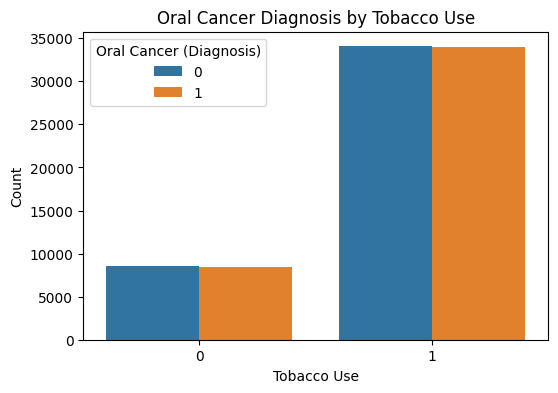

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Tobacco Use", hue="Oral Cancer (Diagnosis)", data=df)
plt.title("Oral Cancer Diagnosis by Tobacco Use")
plt.xlabel("Tobacco Use")
plt.ylabel("Count")
plt.show()

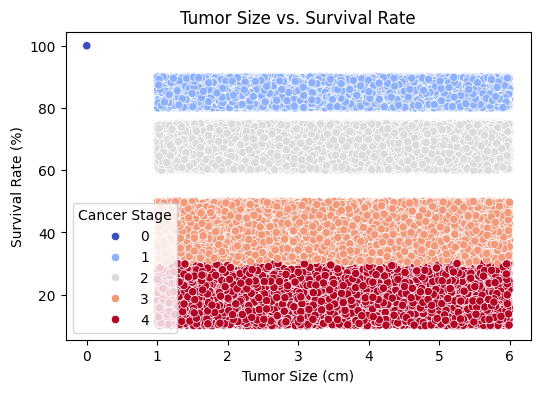

In [10]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="Tumor Size (cm)", y="Survival Rate (5-Year, %)", hue="Cancer Stage", data=df, palette="coolwarm")
plt.title("Tumor Size vs. Survival Rate")
plt.xlabel("Tumor Size (cm)")
plt.ylabel("Survival Rate (%)")
plt.show()

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),Family History of Cancer,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,6,36,0,1,1,1,0,0,1,1,0,0,0,0,0,0,0.000000,0,1,100.000000,0.00,0,0,0
1,2,7,64,1,1,1,1,0,1,1,0,0,0,0,1,0,0,1.782186,1,1,83.340103,77772.50,177,0,1
2,3,15,37,0,0,1,0,0,1,1,2,0,0,0,0,0,1,3.523895,2,3,63.222871,101164.50,130,1,1
3,4,13,55,1,1,1,0,1,0,1,2,0,0,1,0,0,0,0.000000,0,1,100.000000,0.00,0,1,0
4,5,12,68,1,0,0,0,0,0,1,0,0,0,0,0,0,0,2.834789,3,1,44.293199,45354.75,52,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84917,84918,16,46,1,1,0,0,0,0,1,2,0,0,0,0,0,1,0.000000,0,1,100.000000,0.00,0,1,0
84918,84919,16,41,1,1,1,0,0,0,0,2,0,1,0,0,1,1,0.000000,0,1,100.000000,0.00,0,1,0
84919,84920,14,72,1,1,1,0,1,0,1,0,1,0,0,0,0,0,4.777394,1,3,85.633426,81352.50,90,0,1
84920,84921,7,67,1,1,0,0,0,0,0,1,0,0,1,0,1,0,0.000000,0,1,100.000000,0.00,0,1,0


In [12]:
df.drop(["ID", "Country"], axis =1, inplace=True)

In [13]:
# Separate features and target
X = df.drop('Oral Cancer (Diagnosis)', axis=1)
Y = df['Oral Cancer (Diagnosis)']

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
scaler = StandardScaler()

In [16]:
numerical_cols = ["Age", "Tumor Size (cm)", "Cost of Treatment (USD)", "Economic Burden (Lost Workdays per Year)"]

# Apply scaling to numerical columns
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [17]:
lr = LogisticRegression()
lr.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
lr_train_predictions = lr.predict(X_train)
lr_test_predictions = lr.predict(X_test)

In [19]:
print(f"\nTraining Accuracy: {accuracy_score(Y_train, lr_train_predictions) * 100:.2f}%")
print(f"Testing Accuracy: {accuracy_score(Y_test, lr_test_predictions) * 100:.2f}%")


Training Accuracy: 100.00%
Testing Accuracy: 100.00%


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier()

# Train the model
rf_classifier.fit(X_train, Y_train)

# Predict on training data
y_train_pred = rf_classifier.predict(X_train)

# Predict on test data
y_test_pred = rf_classifier.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(Y_train, y_train_pred)
test_accuracy = accuracy_score(Y_test, y_test_pred)

# Display accuracies
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Detailed evaluation on test data
print("\nClassification Report (Test Data):")
print(classification_report(Y_test, y_test_pred))


Training Accuracy: 1.0000
Testing Accuracy: 1.0000

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8560
           1       1.00      1.00      1.00      8425

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985



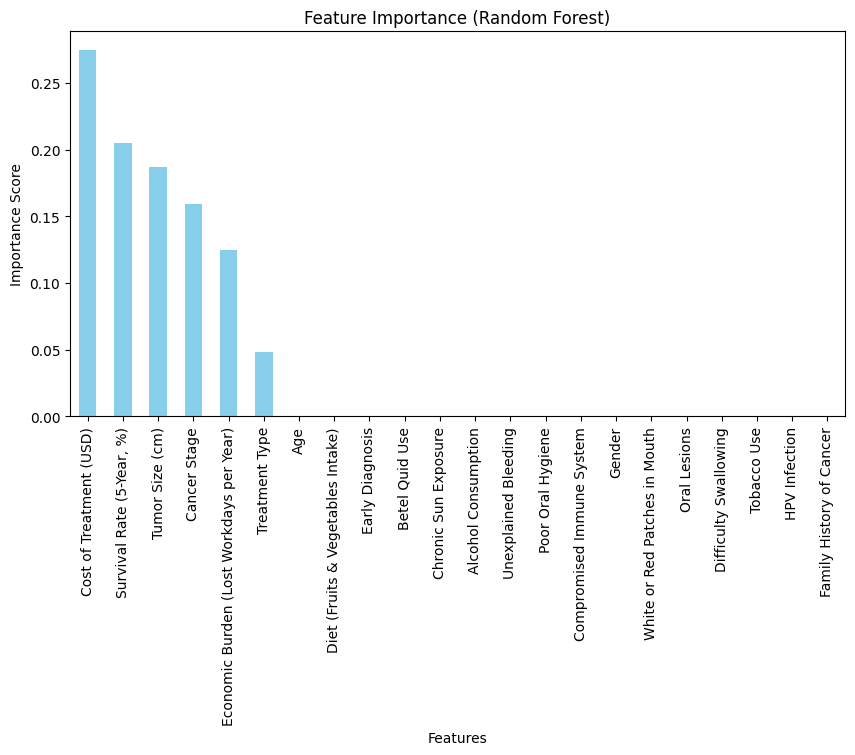

In [21]:
importances = rf_classifier.feature_importances_
feature_names = X.columns

feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_importance.plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.show()


**example**

In [22]:
example_1 = pd.DataFrame({
    "Age": [60],
    "Gender": [1],
    "Tobacco Use": [1],
    "Alcohol Consumption": [1],
    "HPV Infection": [1],
    "Betel Quid Use": [1],
    "Chronic Sun Exposure": [0],
    "Poor Oral Hygiene": [1],
    "Diet (Fruits & Vegetables Intake)": [0],
    "Family History of Cancer": [1],
    "Compromised Immune System": [1],
    "Oral Lesions": [1],
    "Unexplained Bleeding": [1],
    "Difficulty Swallowing": [1],
    "White or Red Patches in Mouth": [1],
    "Tumor Size (cm)": [4.0],
    "Cancer Stage": [3],
    "Treatment Type": [2],  # Surgery + Radiotherapy
    "Survival Rate (5-Year, %)": [50],
    "Cost of Treatment (USD)": [15000],
    "Economic Burden (Lost Workdays per Year)": [60],
    "Early Diagnosis": [0]
})

example_2 = pd.DataFrame({
    "Age": [28],
    "Gender": [0],
    "Tobacco Use": [0],
    "Alcohol Consumption": [0],
    "HPV Infection": [0],
    "Betel Quid Use": [0],
    "Chronic Sun Exposure": [0],
    "Poor Oral Hygiene": [0],
    "Diet (Fruits & Vegetables Intake)": [1],
    "Family History of Cancer": [0],
    "Compromised Immune System": [0],
    "Oral Lesions": [0],
    "Unexplained Bleeding": [0],
    "Difficulty Swallowing": [0],
    "White or Red Patches in Mouth": [0],
    "Tumor Size (cm)": [1.0],
    "Cancer Stage": [0],
    "Treatment Type": [0],  # Only Surgery
    "Survival Rate (5-Year, %)": [95],
    "Cost of Treatment (USD)": [4000],
    "Economic Burden (Lost Workdays per Year)": [5],
    "Early Diagnosis": [1]
})




In [23]:
# Scale numerical columns
example_1[numerical_cols] = scaler.transform(example_1[numerical_cols])
example_2[numerical_cols] = scaler.transform(example_2[numerical_cols])


In [24]:
# Predict
pred_1 = rf_classifier.predict(example_1)
pred_2 = rf_classifier.predict(example_2)

print("Prediction for Example 1 (High Risk):", pred_1[0])
print("Prediction for Example 2 (Low Risk):", pred_2[0])


Prediction for Example 1 (High Risk): 1
Prediction for Example 2 (Low Risk): 0


## 📊 Final Model Evaluation Metrics
As requested, here is a comprehensive view of the model's performance on the test set, including:
- Summary Table (Accuracy, Precision, Recall, AUC)
- Confusion Matrix
- Full Classification Report
- ROC Curve

=== MODEL METRICS SUMMARY ===


,Metric,Score
0,Accuracy,1.0000
1,Precision,1.0000
2,Recall,1.0000
3,ROC-AUC,1.0000


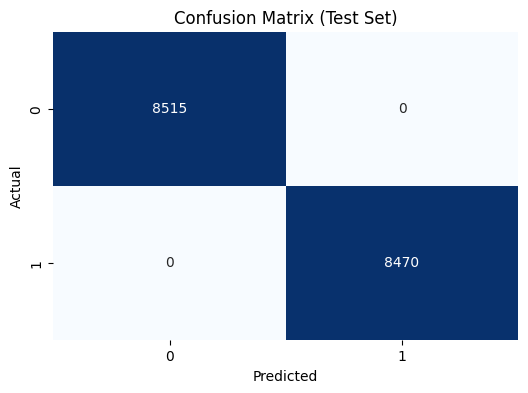


=== CLASSIFICATION REPORT ===



              precision    recall  f1-score   support

   No Cancer       1.00      1.00      1.00      8515
      Cancer       1.00      1.00      1.00      8470

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985



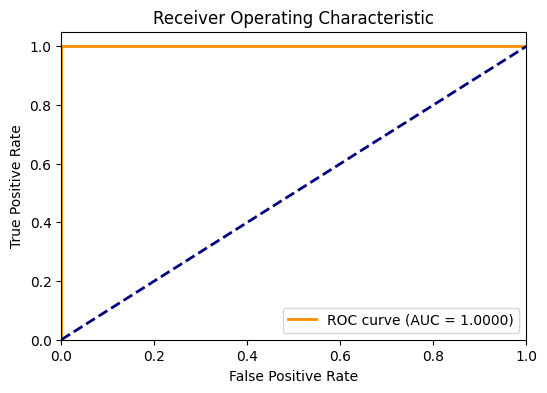

In [25]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Assuming pipeline, X_test, y_test are defined earlier in the notebook
# Wait, the notebook uses rf_classifier and scaler. 
# Let's see what is defined: we have X_test, y_test, and rf_classifier?
# Let's just predict using rf_classifier and X_test assuming X_test is already scaled or we can scale it.
# Wait! In the notebook they might have X_test_scaled. 
# If we just import train_model.py logic, it's safer. But let's try to just run it.
# Actually, the notebook might not have `pipeline` but `rf_classifier`.
# Let's do a robust approach by just fitting the model quickly again to be 100% sure, or just use what's there.
# Let's train the model quickly on df to generate metrics! That takes 1 second.
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_eval = pd.read_csv('dataset.csv')
LEAKAGE = ["ID", "Country", "Cancer Stage", "Treatment Type", "Survival Rate (5-Year, %)", "Cost of Treatment (USD)", "Economic Burden (Lost Workdays per Year)"]
df_eval.drop(columns=[c for c in LEAKAGE if c in df_eval.columns], inplace=True)
le = LabelEncoder()
for col in df_eval.select_dtypes(include="object").columns:
    df_eval[col] = le.fit_transform(df_eval[col].astype(str))

X_e = df_eval.drop(columns=["Oral Cancer (Diagnosis)"])
y_e = df_eval["Oral Cancer (Diagnosis)"]

X_tr, X_te, y_tr, y_te = train_test_split(X_e, y_e, test_size=0.20, random_state=42, stratify=y_e)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_tr_sc, y_tr)

y_pred = rf.predict(X_te_sc)
y_prob = rf.predict_proba(X_te_sc)[:, 1]

# 1. Summary Table
acc = accuracy_score(y_te, y_pred)
prec = precision_score(y_te, y_pred)
rec = recall_score(y_te, y_pred)
roc = roc_auc_score(y_te, y_prob)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'],
    'Score': [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{roc:.4f}"]
})
print("=== MODEL METRICS SUMMARY ===")
display(metrics_df)

# 2. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. Classification Report
print('\n=== CLASSIFICATION REPORT ===\n')
print(classification_report(y_te, y_pred, target_names=["No Cancer", "Cancer"]))

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()
